# Week 4: Importing and Exploring Data - Class Exercises

We first load the packages necessary for this exercise.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import requests

---

## 1. International Visitor Arrivals in Singapore

The file `tourist.csv` (available from `Canvas > Files > data`) contains monthly international visitor arrivals by length of stay from July to December in 2023, 
retrieved from the Singapore Department of Statistics. 

Let’s start by reading in the data as `df` with the standard relative path.

In [5]:
import pandas as pd

df = pd.read_csv('C:/dss5201/data/tourist.csv')
print(df.head())

   Data Series  2023 Dec  2023 Nov  2023 Oct  2023 Sep  2023 Aug  2023 Jul
0  Under 1 Day    259568    240351    236035    227788    248805    269994
1        1 Day    189997    181139    175731    166190    190444    202319
2       2 Days    162209    177977    181721    167772    197076    205910
3       3 Days    168788    168898    189215    172901    210238    216598
4       4 Days    117981    105229    126509    114319    162079    160111


**(A) Data Cleaning**

Examine the dataframe carefully. 

Some of the categories in the column `Data Series` are overlapping. Remove the redundant entry. 

Store the cleaned data frame as `df2`.

(**Hint**: Use `copy()` to create a new independent copy of the cleaned data frame. It makes sure we are not accidentally making changes to the original data frame. Read more [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.copy.html).)

In [6]:
# Type your code here:
# Remove redundant (duplicate) Data Series entries
df2 = df.drop_duplicates(subset="Data Series").copy()

# Optional: check result
print(df2)


       Data Series  2023 Dec  2023 Nov  2023 Oct  2023 Sep  2023 Aug  2023 Jul
0      Under 1 Day    259568    240351    236035    227788    248805    269994
1            1 Day    189997    181139    175731    166190    190444    202319
2           2 Days    162209    177977    181721    167772    197076    205910
3           3 Days    168788    168898    189215    172901    210238    216598
4           4 Days    117981    105229    126509    114319    162079    160111
5           5 Days     64785     56366     69110     62421     98284     98065
6           6 Days     38500     31919     37922     37647     52957     58609
7           7 Days     25082     21058     24014     25955     32983     37887
8        8-10 Days     31446     26251     29618     29818     39565     43611
9       11-14 Days     19370     15348     16519     16837     24048     25987
10  15 Days & Over     36116     32110     33901     34642     51712     47266
11      15-29 Days     25795     22262     23288    

**[Fill in the blank]** After cleaning the data, there are ___13____ non-overlapping categories in `Data Series`.

**(B) Summary Statistics**

The total number of international visitors in December 2023 was ____1149958___ .

In [9]:
total_visitors = df["2023 Dec"].sum()
print(total_visitors)



1149958


**(C) Barplot**

Re-create, as much as you can, the horizontal bar chart below showing the distribution of tourists’ length of stay in December 2023.

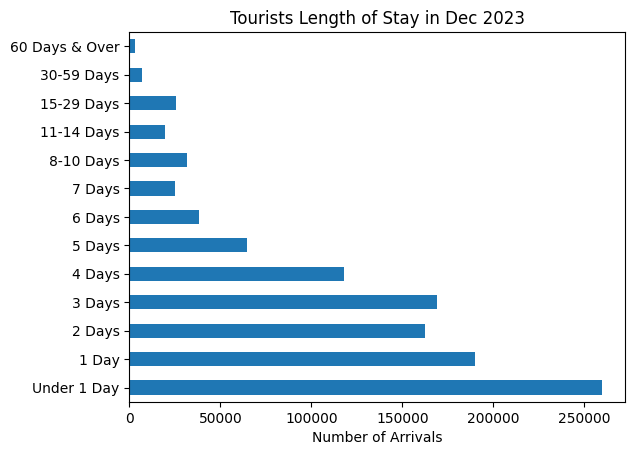

Matplotlib is building the font cache; this may take a moment.


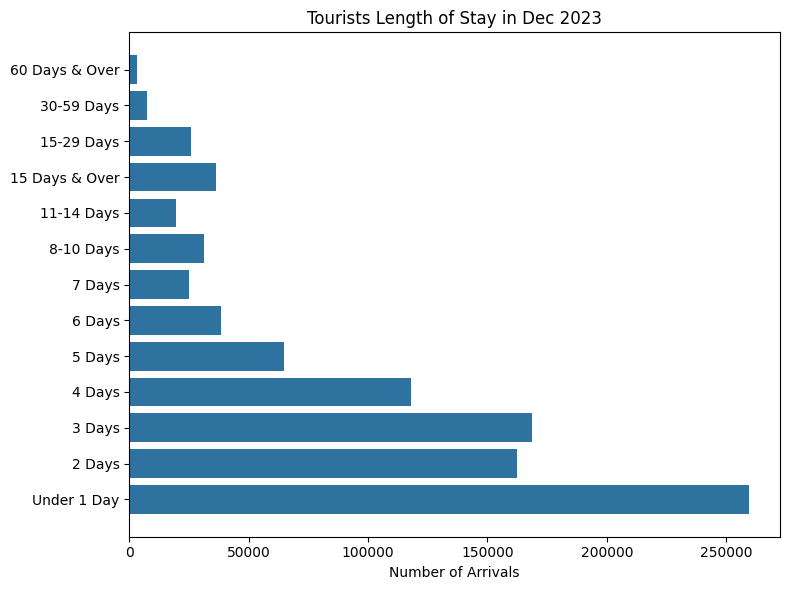

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# keep only length-of-stay rows (if dataset contains other categories)
stay = df[df["Data Series"].str.contains("Days|Under", na=False)]

labels = stay["Data Series"]
values = stay["2023 Dec"]

plt.figure(figsize=(8,6))

plt.barh(labels, values, color="#2E73A0")

plt.xlabel("Number of Arrivals")
plt.title("Tourists Length of Stay in Dec 2023")

plt.tight_layout()
plt.show()


---

## 2. Pupil-Teacher Ratio

There are 5000+ data sets available on [data.gov.sg](https://data.gov.sg).

In this exercise, practice querying and visualizing data on the Pupil-Teacher Ratio (PTR) in primary schools by year. Try reproducing the plot below.

[https://data.gov.sg/datasets/d_bc5a1a10afedf7d25128dae1342c9556/view](https://data.gov.sg/datasets/d_bc5a1a10afedf7d25128dae1342c9556/view)

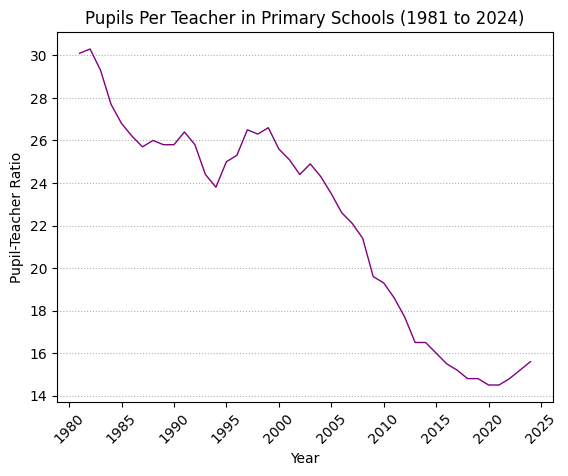


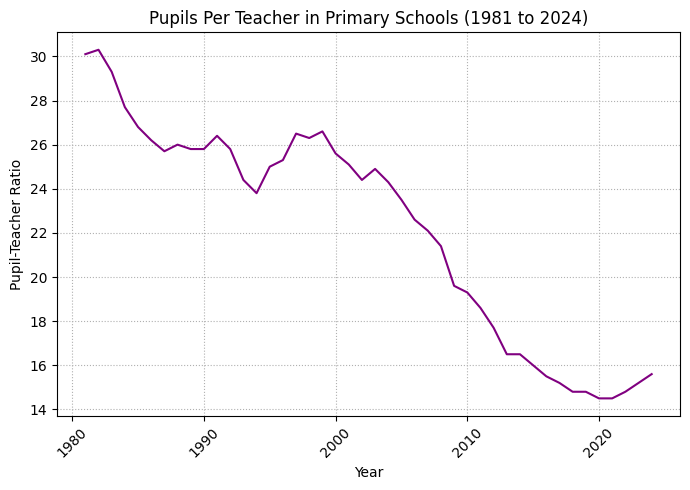

In [16]:
# Type your code here:

import requests
import pandas as pd
import matplotlib.pyplot as plt

dataset_id = "d_bc5a1a10afedf7d25128dae1342c9556"
url = "https://data.gov.sg/api/action/datastore_search?resource_id=" + dataset_id  # API shown on dataset page :contentReference[oaicite:1]{index=1}

# pull all rows (default limit can be small, so set it higher)
resp = requests.get(url, params={"limit": 10000})
resp.raise_for_status()
records = resp.json()["result"]["records"]

df = pd.DataFrame(records)

# clean types + sort by year
df["year"] = df["year"].astype(int)
df["pri_students_to_teachers"] = df["pri_students_to_teachers"].astype(float)
df = df.sort_values("year")

# plot (match the screenshot style as much as possible)
plt.figure(figsize=(7, 5))
plt.plot(df["year"], df["pri_students_to_teachers"], color="purple", linewidth=1.5)

plt.title("Pupils Per Teacher in Primary Schools (1981 to 2024)")
plt.xlabel("Year")
plt.ylabel("Pupil-Teacher Ratio")
plt.grid(True, linestyle=":", linewidth=0.8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
